![banner](../../../docs/figs/brand_identity/banner.png)

# Week 5: Machine Learning 101 — supervised housing prediction

## Lesson overview

Use a labelled dataset to follow a supervised-learning workflow: use features `x` to predict a target `y`, then check the model on data it did not train on.

**By the end, you can:** name the five stages—data, cleaning, splitting, training, and evaluation; distinguish features from the target; and compare linear regression with a decision tree.

**Before you begin:** Run cells in order and keep the training and test sets distinct. Results are examples for this dataset and these settings; they may not apply to other data.

<p align="center"><img src="../figs/ml101_housing_workflow.svg" alt="Housing data split into train and held-out test rows, with separate linear regression and decision-tree paths leading to shared test metrics" width="100%"><br><em>Figure 1. Fit two model types on training rows, then compare both on held-out rows.</em></p>

**Use the figure:** The linear model uses a scaler fitted on training rows; the tree uses the original feature values. In the code, locate each fit step and the true-versus-predicted plot before judging which model worked better.


### The learning loop

<div style="display:flex;gap:12px;align-items:center;flex-wrap:wrap">
<div style="padding:12px;border:1px solid #457b9d;border-radius:8px"><b>Features x</b><br>income, location, rooms</div><span>→</span><div style="padding:12px;border:1px solid #457b9d;border-radius:8px"><b>Model fθ</b><br>linear regression or tree</div><span>→</span><div style="padding:12px;border:1px solid #457b9d;border-radius:8px"><b>Prediction ŷ</b><br>estimated house value</div>
</div>

During training, compare ŷ with the known target y using a loss such as mean squared error: **MSE = average((y − ŷ)²)**. Training adjusts model parameters to reduce this error. Normalisation rescales inputs before fitting; it does not change the target. The notebook's true-versus-predicted plots help inspect test-set errors.

## Purpose and learning outcomes

This notebook is a guided course exercise. It introduces the core idea, follows the existing steps from input to result, and asks you to interpret what the output can and cannot show.

**By the end, you should be able to:**
- describe the main task and the role of its input and output;
- run the notebook in order and explain the result of each major step;
- identify one reasonable extension and one limitation.

## Before you begin

Run the notebook from the repository environment (`ccai9012`) with this repository installed. This lesson uses the repository CSV under `weekly_scripts/wip/week5/`; it does not call an external API. You need pandas, scikit-learn, and matplotlib from the course environment.

## Roadmap and data flow

The workflow is **inspect data → separate features and target → split rows → fit preprocessing on training rows → train models → compare held-out errors and plots**. Input is the local housing CSV; outputs are predictions, metrics, and diagnostic figures. Run cells from top to bottom unless a section says otherwise.

## Machine Learning 101

In this tutorial, we'll build a simple machine learning model to **predict house prices** based on location, income, and housing features.

We’ll use the `housing_price_california.csv` dataset, which includes:
- Median income, house age, rooms, bedrooms
- Population and location (latitude, longitude)
- `Target`: Median house value (the value we want to predict)

---

### Objective

Use available features to predict **`Target`**, the median house price.

---

### What We'll Do

1. Load and explore the data  
2. Clean and normalize the data  
3. Train a model  
4. Evaluate predictions

---

### Models Used

- **Linear Regression** (simple and interpretable)  
- **Decision Tree Regressor** (captures more complex patterns)

We’ll compare the two to understand how different models behave on the same task.

<p align="center"><img src="ml_methods_from_comments.jpg" alt="Housing features feed a model that predicts a target; a separate loss sketch compares candidate regression lines by their prediction errors" width="90%"><br><em>Figure 2. Features enter a model to produce a predicted target; training compares that prediction with the known target using a loss. Source: CCAI 9012 Comments for Kanxuan He, p. 71 (diagram credited there to Prof. Kam-Ming Mark Tam).</em></p>

**Read the diagram:** On the right, the eight housing features are inputs and the target is the value to predict. On the left, the smaller the prediction errors, the better a candidate regression line fits those points. The sketch introduces training; the fitted models and their test errors appear later in this notebook.

In [1]:
# import basic libraries
import numpy as np
import pandas as pd
from ccai9012.paths import WEEKLY_SCRIPTS_DIR

## 1. Data Overview

Check the number of rows, column names, and missing values. Identify the column to predict before cleaning the data.

In [3]:
# read dataset
df = pd.read_csv(WEEKLY_SCRIPTS_DIR / "wip" / "week5" / "housing_price_california.csv", index_col=0)
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [5]:
# Basic info
print("\nData info:\n")
df.info()


Data info:

<class 'pandas.core.frame.DataFrame'>
Index: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.6 MB


## 2. Data Cleaning & Preprocessing

After cleaning, separate the input features from the target. The train/test split holds back some data for checking the model.

In [7]:
# Drop rows with missing values (if any)
df = df.dropna()
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [9]:
# Separate features and target
# X contains the input columns; y contains the value the model will predict.
X = df.drop("Target", axis=1)
y = df["Target"]
display(X)
display(y)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: Target, Length: 20640, dtype: float64

### Feature Scaling (Normalization)

Scaling brings features with different numeric ranges onto a comparable scale. **Predict:** Why should the scaler learn its minimum and maximum only from training rows? The next cell first splits the data, then fits the scaler on training rows and applies that same transformation to test rows.

<p align="center"><img src="normalization_from_comments.jpg" alt="Conceptual comparison of elongated loss contours before normalization and rounder contours after normalization, illustrating why gradient-based optimization can be easier" width="85%"><br><em>Figure 3. Conceptual effect of normalization on an optimization landscape. Source: CCAI 9012 Comments for Kanxuan He, p. 71; the image credits Kam-Ming Mark Tam and community.deeplearning.ai.</em></p>

**Read the diagram:** The left and right landscapes illustrate how very different feature scales can make gradient-based optimization less or more balanced. They are conceptual, not plots generated by this housing model. The `LinearRegression` estimator below does not use gradient descent; here MinMax scaling demonstrates a reusable preprocessing step.

In [11]:
from sklearn.preprocessing import MinMaxScaler

# Split first. Fit scaling on training rows only to keep test information out.
from sklearn.model_selection import train_test_split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)
print("Training feature ranges after scaling:")
for name, low, high in zip(X.columns, X_train.min(axis=0), X_train.max(axis=0)):
    print(f"{name}: {low:.2f} to {high:.2f}")


Training feature ranges after scaling:
MedInc: 0.00 to 1.00
HouseAge: 0.00 to 1.00
AveRooms: 0.00 to 1.00
AveBedrms: 0.00 to 1.00
Population: 0.00 to 1.00
AveOccup: 0.00 to 1.00
Latitude: 0.00 to 1.00
Longitude: 0.00 to 1.00


### Train-test Split

The previous cell used `random_state=42` to make the train/test assignment repeatable. Check the printed row counts; test rows are reserved for evaluation and do not teach the model or set preprocessing parameters.

In [13]:
# The split and training-only scaling were performed in the previous cell.
print("Training rows:", len(X_train), "Test rows:", len(X_test))
print("The held-out rows did not set the scaler's minimum or maximum.")

Training rows: 16512 Test rows: 4128
The held-out rows did not set the scaler's minimum or maximum.


## 3. Train and Test a Linear Regression Model

Fit linear regression, then make predictions for the test data. A prediction is the model estimate; the target is the recorded reference value.

**Before the plots:** Predict where a perfect prediction would fall on a true-versus-predicted chart. **Afterward:** Find one large error and compare MSE with R²; these summarize different aspects of fit, and neither shows whether all groups are served equally well.


In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
# Fit the model using training inputs and their known answers.
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
# Make Predictions
# Ask the fitted model to predict answers for unseen test rows.
y_pred = model.predict(X_test)
y_pred

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251], shape=(4128,))

In [19]:
# Evaluate the Model
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

# Explanation:
# Mean Squared Error (MSE) measures the average squared difference between
# the actual values and the predicted values.
# Lower MSE means predictions are closer to the true values, so better model performance.

# R² compares the model with predicting the test-set mean for every row.
# A value of 1 is perfect; 0 matches that baseline; negative values are worse.


Mean Squared Error (MSE): 0.5558915986952437
R² Score: 0.5757877060324512


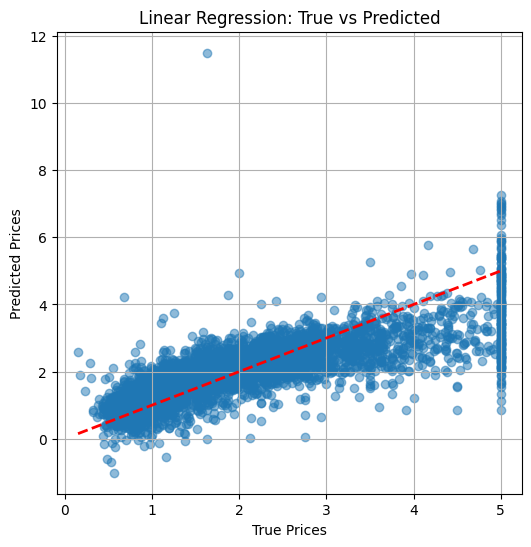

In [21]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Scatter plot: True vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("True Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression: True vs Predicted")
plt.grid(True)
plt.show()

## 4. Train and Test a Decision Tree Model

Train a decision tree and compare it on the same test set. Each node in the tree gives a condition; follow the branches to a leaf to get a prediction.

**Method contrast:** A linear model combines features with one set of coefficients; a tree repeatedly partitions feature ranges. Compare the two on the same held-out rows and identify whether the deeper tree has learned patterns that generalize.


### Decision Tree Regressor: Basic Idea

- The decision tree splits the data into smaller groups based on feature values.  
- At each step, it picks the feature and split point that best separate the data to minimize prediction error.  
- The tree continues splitting until stopping criteria are met (like max depth or minimum samples).  
- It predicts new data by following the splits down the tree to a leaf node, which gives the output value.

Unlike Linear Regression, **Decision Trees do not require normalized data** because they rely on thresholds, not on distances or scales.

---

### Comparing Models

- **Linear Regression** assumes a linear relationship and is sensitive to feature scales, so normalization helps.  
- **Decision Trees** capture non-linear patterns and handle unscaled data well, but can overfit if not controlled.


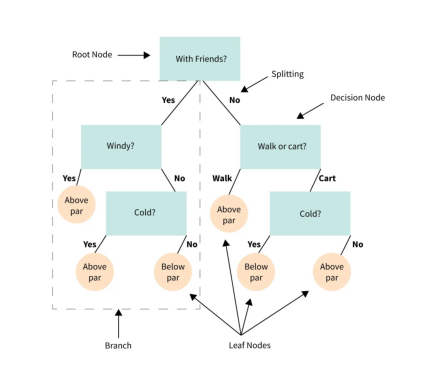

In [23]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread(WEEKLY_SCRIPTS_DIR / "wip" / "week5" / "tree-graphic.webp")

plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()

In [25]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Use original (non-normalized) data for Decision Tree
# Assume X and y are original data (no scaling)
X_train_orig, X_test_orig, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# Train Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_orig, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [30]:
# Predict on test set
y_pred_dt = dt_model.predict(X_test_orig)

In [32]:
# Evaluate
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree MSE: {mse_dt:.4f}")
print(f"Decision Tree R^2: {r2_dt:.4f}")

Decision Tree MSE: 0.4997
Decision Tree R^2: 0.6187


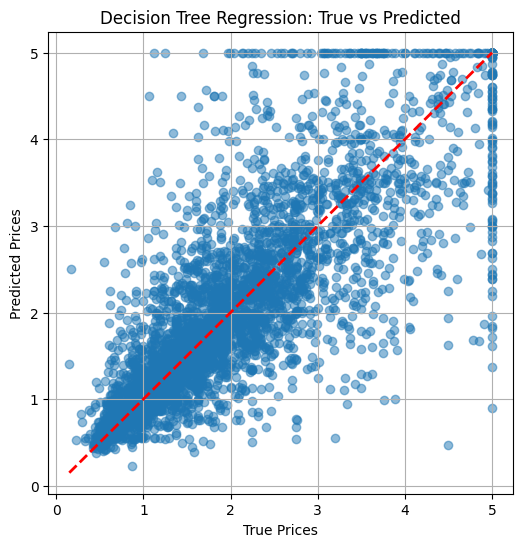

In [34]:
# Scatter plot: True vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_dt, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("True Prices")
plt.ylabel("Predicted Prices")
plt.title("Decision Tree Regression: True vs Predicted")
plt.grid(True)
plt.show()

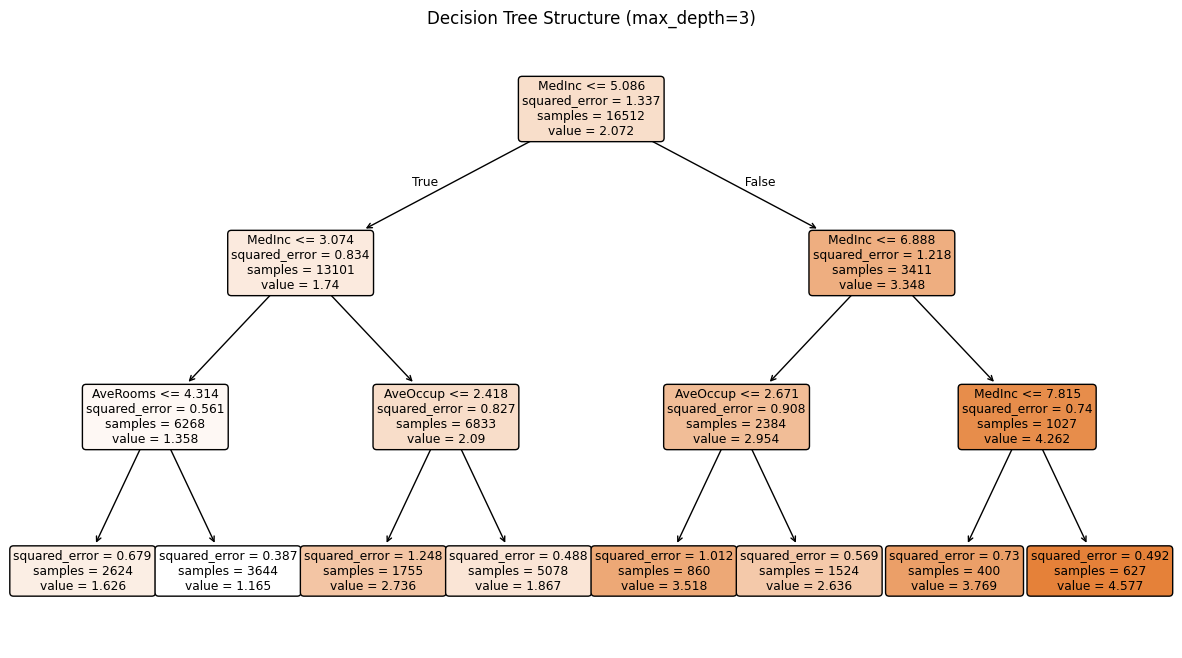

In [36]:
from sklearn.tree import plot_tree

# Train a shallow decision tree with max depth = 3 for easy visualization
dt_model_small = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_model_small.fit(X_train_orig, y_train)

# Plot the shallow tree structure
plt.figure(figsize=(15,8))
plot_tree(
    dt_model_small,
    filled=True,               # Fill nodes with colors
    feature_names=X.columns,   # Show feature names on nodes
    rounded=True               # Rounded corners for nodes
)
plt.title("Decision Tree Structure (max_depth=3)")
plt.show()

### How to read the Decision Tree plot:
- Each box = a decision node or leaf.
- Condition inside (e.g., Feature <= value) splits data into left (True) and right (False) branches.
- Samples: number of data points reaching that node.
- Value: predicted output (average target) at that node.
- Leaves: final predictions with no further splits.

**Pause and trace:** Choose a test row, follow one condition from the root to a leaf, and explain how that leaf produces a prediction. A tree diagram shows this model’s rules, not a causal explanation of housing prices.


## Summary

- We learned how to **load and explore housing price data**.  
- We prepared data by **cleaning** and **scaling** features for regression.  
- We trained two models: **Linear Regression** and **Decision Tree Regression**.  
- We understood basic model **evaluation metrics**:  
  - **Mean Squared Error (MSE)** — measures average squared prediction error, lower is better.  
  - **R-squared (R²)** — indicates how much variance in the target is explained by the model, closer to 1 is better.  
- We visualized predictions using **scatter plots** to compare true vs predicted values.  
- We explored the **Decision Tree structure plot** to understand how the model splits data and makes predictions.  

## What to take away

Supervised learning learns from examples with answers, then uses held-out data to check predictions. **Try next:** Change the train/test split or model settings. **Limit:** Results from one split depend on the sample and random selection.